# Modelos de regresión logística regularizados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data', header=None)
cols = ['ID', 'Diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean',
        'concavity_mean', 'concave_points_mean', 'simmetry_mean', 'fractal_dim_mean', 'radius_sd', 'texture_sd', 'perimeter_sd',
        'area_sd', 'smoothness_sd', 'compactness_sd', 'concavity_sd', 'concave_points_sd', 'simmetry_sd', 'fractal_dim_sd',
        'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst',
        'concavity_worst', 'concave_points_worst', 'simmetry_worst', 'fractal_dim_worst']
df.columns = cols
df.set_index('ID', inplace=True)
df.head()

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,simmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,simmetry_worst,fractal_dim_worst
ID,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diagnosis             569 non-null    object 
 1   radius_mean           569 non-null    float64
 2   texture_mean          569 non-null    float64
 3   perimeter_mean        569 non-null    float64
 4   area_mean             569 non-null    float64
 5   smoothness_mean       569 non-null    float64
 6   compactness_mean      569 non-null    float64
 7   concavity_mean        569 non-null    float64
 8   concave_points_mean   569 non-null    float64
 9   simmetry_mean         569 non-null    float64
 10  fractal_dim_mean      569 non-null    float64
 11  radius_sd             569 non-null    float64
 12  texture_sd            569 non-null    float64
 13  perimeter_sd          569 non-null    float64
 14  area_sd               569 non-null    float64
 15  smoothness_sd        

In [4]:
# Extraccion de matrices de caracteristicas y objetivo, y division de los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

# Codificación de variable a predecir
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Estandarización variables numéricas
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

Tamaño del conjunto de entrenamiento es: (398, 30)
Tamaño del conjunto de prueba es: (171, 30)


La clase `LogisticRegression` tiene 3 hiperparámetros importantes a sintonizar:
- `penalty`: es el tipo de regularización que se quiere aplicar; puede ser 'l2', 'l1' y 'elasticnet'. Este último es una combinación de 'l1' y 'l2'.
- `C`: es el inverso del factor de regularización $\lambda$; este hiperparámetro puede variar en el rango $[0, ∞)$, y mietras más grande sea menos penaliza los coeficientes del modelo.
- `l1-ratio`: este hiperparámetro solo es importante si se ha definido como tipo de penalización a **elasticnet**. Puede variar en el rango $[0,1]$, y determina a que penalización se la dará más peso, mientras más cercano esté a 0 más peso tendrá la penalización 'l2', y mientras más cercano esté a 1 más peso tendrá la penalización 'l1'.

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score

grid = {
    #'penalty':['l1', 'l2', 'elasticnet'], # tipo de regularización
    'C':np.logspace(-3,3,20), # inverso del factor de regularización
    #'l1_ratio':[0, 0.1, 0.5, 0.9, 1] # si tipo de regularización es elasticnet, define que tanto peso se la da a cada tipo de regularización
    }

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        penalty='l2',
        max_iter=10000,
        solver='saga'
        ),
    param_grid=grid,
    #cv=5,
    scoring='precision'
    )

grid_search.fit(X_train, y_train)
#train_score = precision_score(y_train, grid_search.best_estimator_.predict(X_train))
#test_score = precision_score(y_test, grid_search.best_estimator_.predict(X_test))

print(f'Cross-validation score: {grid_search.best_score_:.3f}, best hyperparameters: {grid_search.best_params_}')
print(f'Train score: {grid_search.score(X_train, y_train):.3f}')
print(f'Test score: {grid_search.score(X_test, y_test):.3f}')


Cross-validation score: 1.000, best hyperparameters: {'C': np.float64(0.001)}
Train score: 1.000
Test score: 0.939


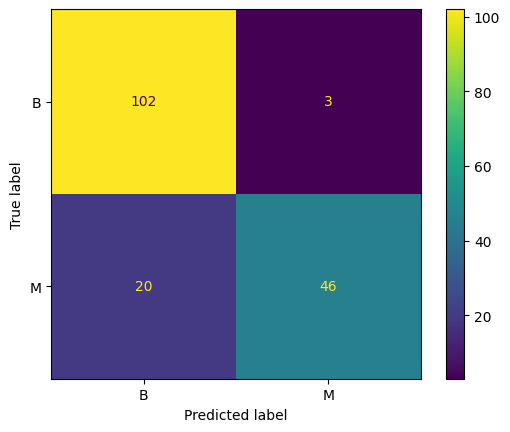

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [19]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    grid_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

           B       0.84      0.97      0.90       105
           M       0.94      0.70      0.80        66

    accuracy                           0.87       171
   macro avg       0.89      0.83      0.85       171
weighted avg       0.88      0.87      0.86       171



In [20]:
# coeficientes del modelo
pesos = pd.DataFrame(grid_search.best_estimator_.coef_, columns=X.columns, index=['Pesos'])
pesos['intercept'] = grid_search.best_estimator_.intercept_
pesos.T.sort_values('Pesos', ascending=False)

,Pesos
concave_points_worst,0.078284
radius_worst,0.075158
perimeter_worst,0.074549
concave_points_mean,0.071156
area_worst,0.069720
perimeter_mean,0.069065
radius_mean,0.068528
concavity_worst,0.067681
area_mean,0.065668
concavity_mean,0.065349


La métrica es importante, observen por ejemplo que pasa cuando se usa *recall*:

In [21]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(
        penalty='l2',
        max_iter=10000,
        solver='saga'
        ),
    param_grid=grid,
    scoring='recall'
    )

grid_search.fit(X_train, y_train)

print(f'Cross-validation score: {grid_search.best_score_:.3f}, best hyperparameters: {grid_search.best_params_}')
print(f'Train score: {grid_search.score(X_train, y_train):.3f}')
print(f'Test score: {grid_search.score(X_test, y_test):.3f}')

Cross-validation score: 0.972, best hyperparameters: {'C': np.float64(1.438449888287663)}
Train score: 0.979
Test score: 0.955


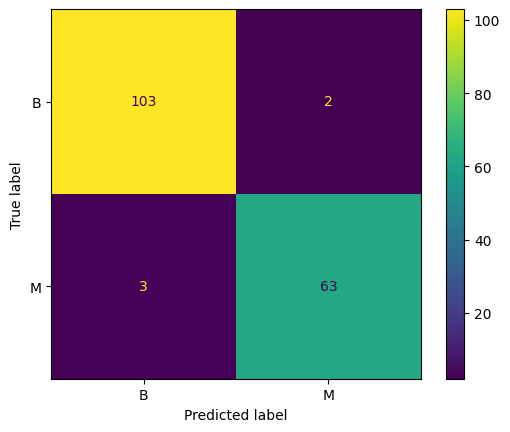

In [22]:
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    )

In [23]:
print(classification_report(
    y_test,
    grid_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

           B       0.97      0.98      0.98       105
           M       0.97      0.95      0.96        66

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [24]:
# coeficientes del modelo
pesos = pd.DataFrame(grid_search.best_estimator_.coef_, columns=X.columns, index=['Pesos'])
pesos['intercept'] = grid_search.best_estimator_.intercept_
pesos.T.sort_values('Pesos', ascending=False)

,Pesos
texture_worst,1.733315
concavity_mean,1.073151
area_worst,1.063595
radius_worst,1.062161
concave_points_worst,1.021457
concave_points_mean,0.980159
perimeter_worst,0.894259
radius_sd,0.854146
smoothness_worst,0.829993
area_sd,0.806654


Con `make_scorer` es posible crear nuevas métricas. En este caso lo vamos a usar para hacer que el modelo apunte a mejorar la precisión en la clase B, que por defecto se tomó como la clase negativa.

In [25]:
from sklearn.metrics import make_scorer, recall_score

scorer = make_scorer(recall_score, pos_label=0) # La clase 'B' se etiquetó como 0

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        penalty='l2',
        max_iter=10000,
        solver='saga'
        ),
    param_grid=grid,
    scoring=scorer
    )

grid_search.fit(X_train, y_train)

print(f'Cross-validation score: {grid_search.best_score_:.3f}, best hyperparameters: {grid_search.best_params_}')
print(f'Train score: {grid_search.score(X_train, y_train):.3f}')
print(f'Test score: {grid_search.score(X_test, y_test):.3f}')

Cross-validation score: 1.000, best hyperparameters: {'C': np.float64(0.001)}
Train score: 1.000
Test score: 0.971


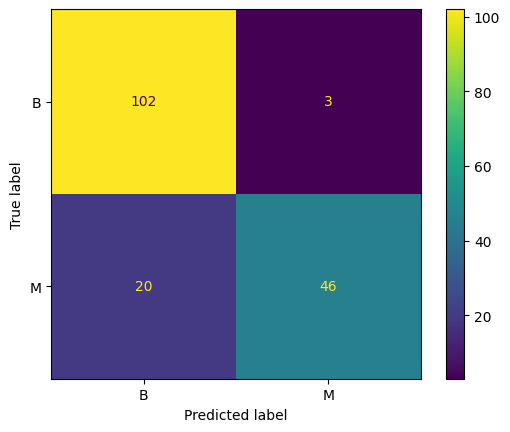

In [26]:
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    )

In [28]:
print(classification_report(
    y_test,
    grid_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

           B       0.84      0.97      0.90       105
           M       0.94      0.70      0.80        66

    accuracy                           0.87       171
   macro avg       0.89      0.83      0.85       171
weighted avg       0.88      0.87      0.86       171



In [29]:
# coeficientes del modelo
pesos = pd.DataFrame(grid_search.best_estimator_.coef_, columns=X.columns, index=['Pesos'])
pesos['intercept'] = grid_search.best_estimator_.intercept_
pesos.T.sort_values('Pesos', ascending=False)

,Pesos
concave_points_worst,0.078288
radius_worst,0.075160
perimeter_worst,0.074551
concave_points_mean,0.071157
area_worst,0.069720
perimeter_mean,0.069069
radius_mean,0.068532
concavity_worst,0.067682
area_mean,0.065670
concavity_mean,0.065349
